# Relevant Imports

In [1]:
import numpy as np
import pandas as pd
import torch
import warnings
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import TimeSeriesSplit

from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from transformers import BertTokenizer, BertModel
from transformers import AutoConfig
from transformers import Trainer, TrainingArguments

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef
)

# Ignore all warnings
warnings.filterwarnings("ignore")

# Data Preprocessing

In [2]:
filepath = '../../dataset_final/FinSen_S&P500/multimodal_S&P500_all.csv'
filepath_num = '../../dataset_final/FinSen_S&P500/merged_S&P500.csv'
data = pd.read_csv(filepath)
data_num = pd.read_csv(filepath_num)
data.head()
data_num.head()

,Unnamed: 0,Date,Open,Close,High,Volume,aggregate_sentiment_score,Movement,Daily_Return,Volatility,sentiment_volatility,sentiment_volatility_lag1,aggregate_sentiment_score_lag1,Close_lag1,High_lag1,Volume_lag1,Daily_Return_lag1,Volatility_lag1
0,12,2007-08-01,1455.18,1465.81,1468.38,5.256780e+09,-0.15,0,0.724264,1.257202,0.270222,0.268142,0.00,1455.27,1488.30,4.524520e+09,-0.251552,0.991957
1,13,2007-08-07,1467.61,1476.70,1488.30,4.909390e+09,0.00,1,0.742934,1.384401,0.262336,0.270222,-0.15,1465.81,1468.38,5.256780e+09,0.724264,1.257202
2,14,2007-08-10,1453.08,1453.64,1462.02,5.345780e+09,-0.67,0,-1.561590,1.159805,0.367736,0.262336,0.00,1476.70,1488.30,4.909390e+09,0.742934,1.384401
3,15,2007-08-13,1453.42,1452.92,1466.29,3.696280e+09,-0.20,0,-0.049531,0.942009,0.275372,0.367736,-0.67,1453.64,1462.02,5.345780e+09,-1.561590,1.159805
4,16,2007-08-14,1452.86,1426.54,1456.73,3.814630e+09,-0.23,0,-1.815654,1.229445,0.250898,0.275372,-0.20,1452.92,1466.29,3.696280e+09,-0.049531,0.942009


In [3]:
data.head()

,Unnamed: 0,Date,Open,Movement,sentiment_volatility_lag1,aggregate_sentiment_score_lag1,Close_lag1,High_lag1,Volume_lag1,Daily_Return_lag1,Volatility_lag1,garch_cond_variance_lag1,garch_cond_volatility_lag1,garch_residuals_lag1,rolling_cond_volatility_3_lag1,rolling_cond_volatility_5_lag1,Title,cleaned_content
0,0,2007-08-01,1455.18,0,0.268142,0.00,1455.27,1488.30,4.524520e+09,-0.251552,0.991957,NaN,NaN,NaN,NaN,NaN,U.S. Companies added the smallest number of jo...,U.S. Companies added the smallest number of jo...
1,1,2007-08-07,1467.61,1,0.270222,-0.15,1465.81,1468.38,5.256780e+09,0.724264,1.257202,1.440581,1.200242,0.721654,NaN,NaN,US Federal Reserve keeps interest rates unchan...,US Federal Reserve keeps interest rates unchan...
2,2,2007-08-10,1453.08,0,0.262336,0.00,1476.70,1488.30,4.909390e+09,0.742934,1.384401,1.311621,1.145260,0.740188,NaN,NaN,Stock Markets Fall Worldwide! Recession?,Stock Markets Fall Worldwide! Recession?United...
3,3,2007-08-13,1453.42,0,0.367736,-0.67,1453.64,1462.02,5.345780e+09,-1.561590,1.159805,1.517074,1.231695,-1.573911,1.423092,NaN,Goldman Sachs fights back by putting $3 billio...,Goldman Sachs fights back by putting $3 billio...
4,4,2007-08-14,1452.86,0,0.275372,-0.20,1452.92,1466.29,3.696280e+09,-0.049531,0.942009,1.286727,1.134340,-0.049543,1.371807,NaN,U.S. Trade Deficit Narrows in June to $58.1 Bln,U.S. Trade Deficit Narrows in June to $58.1 Bl...


In [4]:
# 1) Make sure Date is datetime
data['Date'] = pd.to_datetime(data['Date'])
data_num['Date'] = pd.to_datetime(data_num['Date'])


In [5]:
# 2) Get all rows in `data` that have a duplicate Date (shows every occurrence)
dupes_all = data[data.duplicated(subset='Date', keep=False)]
print(f"Found {len(dupes_all)} rows in `data` with non-unique dates:")
print(dupes_all.sort_values('Date').head(10))


Found 14621 rows in `data` with non-unique dates:
    Unnamed: 0       Date     Open  Movement  sentiment_volatility_lag1  \
9            9 2007-08-28  1466.71         1                   0.097622   
10          10 2007-08-28  1466.71         1                   0.097622   
20          20 2007-09-18  1476.63         0                   0.239332   
21          21 2007-09-18  1476.63         0                   0.239332   
27          27 2007-09-27  1527.31         1                   0.211258   
28          28 2007-09-27  1527.31         1                   0.211258   
32          32 2007-10-11  1564.71         1                   0.144465   
33          33 2007-10-11  1564.71         1                   0.144465   
34          34 2007-10-12  1555.41         1                   0.294873   
35          35 2007-10-12  1555.41         1                   0.294873   

    aggregate_sentiment_score_lag1  Close_lag1  High_lag1   Volume_lag1  \
9                            -0.05     1445.55   

In [6]:
# Convert the Date columns to datetime
data['Date'] = pd.to_datetime(data['Date'])
data_num['Date'] = pd.to_datetime(data_num['Date'])

# Merge data with the Daily_Return column from data_num using an inner join
merged_data = pd.merge(data, data_num[['Date', 'Daily_Return']], on='Date', how='inner')

# Optionally, view the result
merged_data.head()

,Unnamed: 0,Date,Open,Movement,sentiment_volatility_lag1,aggregate_sentiment_score_lag1,Close_lag1,High_lag1,Volume_lag1,Daily_Return_lag1,Volatility_lag1,garch_cond_variance_lag1,garch_cond_volatility_lag1,garch_residuals_lag1,rolling_cond_volatility_3_lag1,rolling_cond_volatility_5_lag1,Title,cleaned_content,Daily_Return
0,0,2007-08-01,1455.18,0,0.268142,0.00,1455.27,1488.30,4.524520e+09,-0.251552,0.991957,NaN,NaN,NaN,NaN,NaN,U.S. Companies added the smallest number of jo...,U.S. Companies added the smallest number of jo...,0.724264
1,1,2007-08-07,1467.61,1,0.270222,-0.15,1465.81,1468.38,5.256780e+09,0.724264,1.257202,1.440581,1.200242,0.721654,NaN,NaN,US Federal Reserve keeps interest rates unchan...,US Federal Reserve keeps interest rates unchan...,0.742934
2,2,2007-08-10,1453.08,0,0.262336,0.00,1476.70,1488.30,4.909390e+09,0.742934,1.384401,1.311621,1.145260,0.740188,NaN,NaN,Stock Markets Fall Worldwide! Recession?,Stock Markets Fall Worldwide! Recession?United...,-1.561590
3,3,2007-08-13,1453.42,0,0.367736,-0.67,1453.64,1462.02,5.345780e+09,-1.561590,1.159805,1.517074,1.231695,-1.573911,1.423092,NaN,Goldman Sachs fights back by putting $3 billio...,Goldman Sachs fights back by putting $3 billio...,-0.049531
4,4,2007-08-14,1452.86,0,0.275372,-0.20,1452.92,1466.29,3.696280e+09,-0.049531,0.942009,1.286727,1.134340,-0.049543,1.371807,NaN,U.S. Trade Deficit Narrows in June to $58.1 Bln,U.S. Trade Deficit Narrows in June to $58.1 Bl...,-1.815654


In [7]:
if 'Unnamed: 0' in merged_data.columns:
    merged_data = merged_data.drop(columns=['Unnamed: 0'])
merged_data.head()


,Date,Open,Movement,sentiment_volatility_lag1,aggregate_sentiment_score_lag1,Close_lag1,High_lag1,Volume_lag1,Daily_Return_lag1,Volatility_lag1,garch_cond_variance_lag1,garch_cond_volatility_lag1,garch_residuals_lag1,rolling_cond_volatility_3_lag1,rolling_cond_volatility_5_lag1,Title,cleaned_content,Daily_Return
0,2007-08-01,1455.18,0,0.268142,0.00,1455.27,1488.30,4.524520e+09,-0.251552,0.991957,NaN,NaN,NaN,NaN,NaN,U.S. Companies added the smallest number of jo...,U.S. Companies added the smallest number of jo...,0.724264
1,2007-08-07,1467.61,1,0.270222,-0.15,1465.81,1468.38,5.256780e+09,0.724264,1.257202,1.440581,1.200242,0.721654,NaN,NaN,US Federal Reserve keeps interest rates unchan...,US Federal Reserve keeps interest rates unchan...,0.742934
2,2007-08-10,1453.08,0,0.262336,0.00,1476.70,1488.30,4.909390e+09,0.742934,1.384401,1.311621,1.145260,0.740188,NaN,NaN,Stock Markets Fall Worldwide! Recession?,Stock Markets Fall Worldwide! Recession?United...,-1.561590
3,2007-08-13,1453.42,0,0.367736,-0.67,1453.64,1462.02,5.345780e+09,-1.561590,1.159805,1.517074,1.231695,-1.573911,1.423092,NaN,Goldman Sachs fights back by putting $3 billio...,Goldman Sachs fights back by putting $3 billio...,-0.049531
4,2007-08-14,1452.86,0,0.275372,-0.20,1452.92,1466.29,3.696280e+09,-0.049531,0.942009,1.286727,1.134340,-0.049543,1.371807,NaN,U.S. Trade Deficit Narrows in June to $58.1 Bln,U.S. Trade Deficit Narrows in June to $58.1 Bl...,-1.815654


In [8]:
merged_data.columns

Index(['Date', 'Open', 'Movement', 'sentiment_volatility_lag1',
       'aggregate_sentiment_score_lag1', 'Close_lag1', 'High_lag1',
       'Volume_lag1', 'Daily_Return_lag1', 'Volatility_lag1',
       'garch_cond_variance_lag1', 'garch_cond_volatility_lag1',
       'garch_residuals_lag1', 'rolling_cond_volatility_3_lag1',
       'rolling_cond_volatility_5_lag1', 'Title', 'cleaned_content',
       'Daily_Return'],
      dtype='object')

In [9]:
# Handling missing values in rolling features
rolling_features = [
    'garch_cond_variance_lag1', 
    'garch_cond_volatility_lag1',
       'garch_residuals_lag1', 
    'rolling_cond_volatility_3_lag1',
       'rolling_cond_volatility_5_lag1'
]  # Add any other rolling features here

# Drop rows with missing values
merged_data = merged_data.drop(columns=rolling_features).reset_index(drop=True)
merged_data.head()

,Date,Open,Movement,sentiment_volatility_lag1,aggregate_sentiment_score_lag1,Close_lag1,High_lag1,Volume_lag1,Daily_Return_lag1,Volatility_lag1,Title,cleaned_content,Daily_Return
0,2007-08-01,1455.18,0,0.268142,0.00,1455.27,1488.30,4.524520e+09,-0.251552,0.991957,U.S. Companies added the smallest number of jo...,U.S. Companies added the smallest number of jo...,0.724264
1,2007-08-07,1467.61,1,0.270222,-0.15,1465.81,1468.38,5.256780e+09,0.724264,1.257202,US Federal Reserve keeps interest rates unchan...,US Federal Reserve keeps interest rates unchan...,0.742934
2,2007-08-10,1453.08,0,0.262336,0.00,1476.70,1488.30,4.909390e+09,0.742934,1.384401,Stock Markets Fall Worldwide! Recession?,Stock Markets Fall Worldwide! Recession?United...,-1.561590
3,2007-08-13,1453.42,0,0.367736,-0.67,1453.64,1462.02,5.345780e+09,-1.561590,1.159805,Goldman Sachs fights back by putting $3 billio...,Goldman Sachs fights back by putting $3 billio...,-0.049531
4,2007-08-14,1452.86,0,0.275372,-0.20,1452.92,1466.29,3.696280e+09,-0.049531,0.942009,U.S. Trade Deficit Narrows in June to $58.1 Bln,U.S. Trade Deficit Narrows in June to $58.1 Bl...,-1.815654


In [10]:
merged_data.head()

,Date,Open,Movement,sentiment_volatility_lag1,aggregate_sentiment_score_lag1,Close_lag1,High_lag1,Volume_lag1,Daily_Return_lag1,Volatility_lag1,Title,cleaned_content,Daily_Return
0,2007-08-01,1455.18,0,0.268142,0.00,1455.27,1488.30,4.524520e+09,-0.251552,0.991957,U.S. Companies added the smallest number of jo...,U.S. Companies added the smallest number of jo...,0.724264
1,2007-08-07,1467.61,1,0.270222,-0.15,1465.81,1468.38,5.256780e+09,0.724264,1.257202,US Federal Reserve keeps interest rates unchan...,US Federal Reserve keeps interest rates unchan...,0.742934
2,2007-08-10,1453.08,0,0.262336,0.00,1476.70,1488.30,4.909390e+09,0.742934,1.384401,Stock Markets Fall Worldwide! Recession?,Stock Markets Fall Worldwide! Recession?United...,-1.561590
3,2007-08-13,1453.42,0,0.367736,-0.67,1453.64,1462.02,5.345780e+09,-1.561590,1.159805,Goldman Sachs fights back by putting $3 billio...,Goldman Sachs fights back by putting $3 billio...,-0.049531
4,2007-08-14,1452.86,0,0.275372,-0.20,1452.92,1466.29,3.696280e+09,-0.049531,0.942009,U.S. Trade Deficit Narrows in June to $58.1 Bln,U.S. Trade Deficit Narrows in June to $58.1 Bl...,-1.815654


In [11]:
merged_data.value_counts

<bound method DataFrame.value_counts of             Date     Open  Movement  sentiment_volatility_lag1  \
0     2007-08-01  1455.18         0                   0.268142   
1     2007-08-07  1467.61         1                   0.270222   
2     2007-08-10  1453.08         0                   0.262336   
3     2007-08-13  1453.42         0                   0.367736   
4     2007-08-14  1452.86         0                   0.275372   
...          ...      ...       ...                        ...   
15230 2023-07-14  4514.60         1                   0.504529   
15231 2023-07-14  4514.60         1                   0.504529   
15232 2023-07-14  4514.60         1                   0.504529   
15233 2023-07-14  4514.60         1                   0.504529   
15234 2023-07-14  4514.60         1                   0.504529   

       aggregate_sentiment_score_lag1  Close_lag1  High_lag1   Volume_lag1  \
0                                0.00     1455.27    1488.30  4.524520e+09   
1          

In [12]:
merged_data.columns

Index(['Date', 'Open', 'Movement', 'sentiment_volatility_lag1',
       'aggregate_sentiment_score_lag1', 'Close_lag1', 'High_lag1',
       'Volume_lag1', 'Daily_Return_lag1', 'Volatility_lag1', 'Title',
       'cleaned_content', 'Daily_Return'],
      dtype='object')

# Generate embeddings

## a. Textual Embeddings

In [13]:
# ----------------------------
# Set device: use Apple MPS if available, otherwise CPU
# ----------------------------
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("Using device:", device)

# ----------------------------
# Define the paths and model identifiers
# ----------------------------
# Path to your finetuned model weights
finetuned_model_path = "./minilm_finphrasebank_final_model/"
# Use the base model identifier to load the tokenizer since the tokenizer files are not present locally
base_model_name = "microsoft/MiniLM-L12-H384-uncased"

# ----------------------------
# Load the tokenizer from the base model and the finetuned model from your local directory
# ----------------------------
tokenizer = AutoTokenizer.from_pretrained(base_model_name)
model = AutoModelForSequenceClassification.from_pretrained(finetuned_model_path)
model.to(device)
model.eval()

def get_embedding(text):
    """
    Generate an embedding for the input text using the finetuned MiniLM-L12-H384-uncased model.
    Returns the first token's (CLS token's) embedding as the sentence representation.
    """
    # Tokenize text with a maximum length of 512 tokens
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    # Move inputs to the selected device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        # Access the underlying encoder by using model.base_model to bypass the classification head
        outputs = model.base_model(**inputs)
    # Extract the CLS token embedding (first token) and move it to CPU
    first_token_embedding = outputs.last_hidden_state[:, 0, :]
    return first_token_embedding.squeeze(0).cpu().numpy()

# ----------------------------
# Load and sort the dataset
# ----------------------------
df = merged_data.copy()  # Assumes 'merged_data' is defined elsewhere
df['Date'] = pd.to_datetime(df['Date'])

# ----------------------------
# Iterate over all unique dates to compute aggregated embedding
# using the last available date (with articles) in the dataset
# ----------------------------
unique_dates = np.sort(df['Date'].unique())
prev_date_embeddings = {}

for current_date in unique_dates:
    # Get all dates strictly less than the current_date
    available_dates = df[df['Date'] < current_date]['Date']
    if available_dates.empty:
        print(f"No previous date available for {pd.Timestamp(current_date).date()}. Using zero vector.")
        embedding = np.zeros(model.config.hidden_size, dtype=np.float32)
    else:
        # Use the last available date prior to current_date
        last_available_date = available_dates.max()
        print(f"For current date {pd.Timestamp(current_date).date()}, last available date is {pd.Timestamp(last_available_date).date()}")
        
        # Retrieve articles for that date
        articles = df[df['Date'] == last_available_date]['cleaned_content']
        if articles.empty:
            print(f"No articles found for date {pd.Timestamp(last_available_date).date()}, using zero vector.")
            embedding = np.zeros(model.config.hidden_size, dtype=np.float32)
        else:
            embeddings = [get_embedding(article) for article in articles]
            embedding = np.mean(embeddings, axis=0)
    prev_date_embeddings[current_date] = embedding

# Map the computed embeddings back to the DataFrame
df['prev_day_embedding'] = df['Date'].map(prev_date_embeddings)

# Debug print: check the embedding shape for the first row
print("First row aggregated previous date embedding shape:", df.iloc[0]['prev_day_embedding'].shape)


Using device: mps
No previous date available for 2007-08-01. Using zero vector.
For current date 2007-08-07, last available date is 2007-08-01
For current date 2007-08-10, last available date is 2007-08-07
For current date 2007-08-13, last available date is 2007-08-10
For current date 2007-08-14, last available date is 2007-08-13
For current date 2007-08-15, last available date is 2007-08-14
For current date 2007-08-16, last available date is 2007-08-15
For current date 2007-08-17, last available date is 2007-08-16
For current date 2007-08-20, last available date is 2007-08-17
For current date 2007-08-28, last available date is 2007-08-20
For current date 2007-08-29, last available date is 2007-08-28
For current date 2007-08-30, last available date is 2007-08-29
For current date 2007-08-31, last available date is 2007-08-30
For current date 2007-09-04, last available date is 2007-08-31
For current date 2007-09-07, last available date is 2007-09-04
For current date 2007-09-10, last avai

In [14]:
'''# ----------------------------
# Set device: use Apple MPS if available, otherwise CPU
# ----------------------------
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("Using device:", device)

# ----------------------------
# Load MiniLM-L12-H384-uncased model and tokenizer
# ----------------------------
model_name = "microsoft/MiniLM-L12-H384-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.to(device)
model.eval()

def get_embedding(text):
    """
    Generate an embedding for the input text using MiniLM-L12-H384-uncased on the specified device.
    Returns the first token's embedding as the sentence representation.
    """
    # Set max_length to 512 tokens (default for MiniLM)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    # Move inputs to the device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    # Use the first token's embedding as the sentence representation
    first_token_embedding = outputs.last_hidden_state[:, 0, :]  # shape: (1, hidden_size)
    # Move embedding back to CPU before converting to numpy
    return first_token_embedding.squeeze(0).cpu().numpy()

# ----------------------------
# Load and sort the dataset
# ----------------------------
df = merged_data.copy()  # Assumes 'merged_data' is already defined elsewhere
df['Date'] = pd.to_datetime(df['Date'])

# ----------------------------
# Iterate over all unique dates to compute aggregated embedding
# using the last available date (with articles) in the dataset
# ----------------------------
unique_dates = np.sort(df['Date'].unique())
prev_date_embeddings = {}

for current_date in unique_dates:
    # Get all dates strictly less than the current_date
    available_dates = df[df['Date'] < current_date]['Date']
    if available_dates.empty:
        print(f"No previous date available for {pd.Timestamp(current_date).date()}. Using zero vector.")
        embedding = np.zeros(model.config.hidden_size, dtype=np.float32)
    else:
        # Use the last available date prior to current_date
        last_available_date = available_dates.max()
        print(f"For current date {pd.Timestamp(current_date).date()}, last available date is {pd.Timestamp(last_available_date).date()}")
        
        # Retrieve articles for that date
        articles = df[df['Date'] == last_available_date]['cleaned_content']
        if articles.empty:
            print(f"No articles found for date {pd.Timestamp(last_available_date).date()}, using zero vector.")
            embedding = np.zeros(model.config.hidden_size, dtype=np.float32)
        else:
            embeddings = [get_embedding(article) for article in articles]
            embedding = np.mean(embeddings, axis=0)
    prev_date_embeddings[current_date] = embedding

# Map the computed embeddings back to the DataFrame
df['prev_day_embedding'] = df['Date'].map(prev_date_embeddings)

# Debug print: check the embedding shape for the first row
print("First row aggregated previous date embedding shape:", df.iloc[0]['prev_day_embedding'].shape) '''

'# ----------------------------\n# Set device: use Apple MPS if available, otherwise CPU\n# ----------------------------\ndevice = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")\nprint("Using device:", device)\n\n# ----------------------------\n# Load MiniLM-L12-H384-uncased model and tokenizer\n# ----------------------------\nmodel_name = "microsoft/MiniLM-L12-H384-uncased"\ntokenizer = AutoTokenizer.from_pretrained(model_name)\nmodel = AutoModel.from_pretrained(model_name)\nmodel.to(device)\nmodel.eval()\n\ndef get_embedding(text):\n    """\n    Generate an embedding for the input text using MiniLM-L12-H384-uncased on the specified device.\n    Returns the first token\'s embedding as the sentence representation.\n    """\n    # Set max_length to 512 tokens (default for MiniLM)\n    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)\n    # Move inputs to the device\n    inputs = {k: v.to(device) for k, v in inputs.items()}

## b. Numerical Embeddings

In [15]:
from sklearn.preprocessing import StandardScaler
import joblib

numerical_cols = [
    'Open','sentiment_volatility_lag1','aggregate_sentiment_score_lag1',
    'Close_lag1','High_lag1','Volume_lag1','Daily_Return_lag1','Volatility_lag1'
]

# ----------------------------
# 1) Fit & save your scaler
# ----------------------------
scaler = StandardScaler()
# If you’re doing a train/test split, call scaler.fit(...) on train only;
# here we just fit on the whole df for illustration:
scaler.fit(df[numerical_cols])

# **SAVE** immediately after fit, before any transform on new data
joblib.dump(scaler, 'artifacts/numeric_scaler.joblib')

# ----------------------------
# 2) Transform your data
# ----------------------------
df[numerical_cols] = scaler.transform(df[numerical_cols])

# ----------------------------
# 3) Create market_vector as before
# ----------------------------
def create_market_vector(row):
    num_features    = row[numerical_cols].to_numpy(dtype=np.float64)
    text_embedding  = row['prev_day_embedding']
    return np.concatenate([num_features, text_embedding])

df['market_vector'] = df.apply(create_market_vector, axis=1)

print("Market vector shape for the first row:", df.iloc[0]['market_vector'].shape)


Market vector shape for the first row: (392,)


In [16]:
df['prev_day_embedding'].head(10)

0    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
1    [-0.07720111, -0.11580781, 0.10278951, 0.22265...
2    [0.023636034, -0.12582204, 0.2505246, 0.219310...
3    [0.028550323, -0.21866547, 0.05700311, 0.08041...
4    [-0.034655236, -0.07474289, 0.4177648, 0.42095...
5    [-0.14754783, -0.07328823, 0.25512245, 0.38963...
6    [-0.16135445, 0.009911662, 0.40212822, 0.51390...
7    [-0.12739134, -0.052670494, 0.34488556, 0.4429...
8    [0.041883472, -0.10528456, 0.35592243, 0.36974...
9    [-0.05693379, -0.12148855, 0.18687373, 0.26981...
Name: prev_day_embedding, dtype: object

## Cosine similarity between embeddings

In [17]:
# ----------------------------
# Assume 'df' already contains:
# - Scaled numerical features in columns defined by `numerical_cols`
# - The aggregated textual embedding in the column 'prev_day_embedding' (each is 768-dim)
# ----------------------------

df1 = df.copy()

# 1. Extract all aggregated textual embeddings into a matrix (n_samples x 768)
# Note: Ensure that all embeddings are in a consistent shape.
text_embeddings = np.stack(df1['prev_day_embedding'].values)  # shape: (n_samples, 768)

# 2. Reduce textual embeddings to 13 dimensions using PCA for comparison
pca = PCA(n_components=8)
text_embeddings_reduced = pca.fit_transform(text_embeddings)  # shape: (n_samples, 14)

# 3. For each day, compute cosine similarity between the numerical features and the reduced textual embedding.
similarities = []
for i, row in df1.iterrows():
    # Extract the scaled numerical features (14-dimensional)
    num_features = row[numerical_cols].to_numpy(dtype=np.float64).reshape(1, -1)  # shape: (1, 14)
    
    # Get the corresponding reduced textual embedding (14-dimensional)
    text_emb = text_embeddings_reduced[i].reshape(1, -1)  # shape: (1, 14)
    
    # Compute cosine similarity between these two 14-dim vectors
    sim = cosine_similarity(num_features, text_emb)[0, 0]
    similarities.append(sim)

# 4. Save and inspect the similarity scores
df1['num_text_similarity'] = similarities

# Debug print: Summary statistics for the cosine similarity across days
print("Cosine similarity between numerical and (PCA-reduced) textual embeddings per day:")
print(df1['num_text_similarity'].describe())


Cosine similarity between numerical and (PCA-reduced) textual embeddings per day:
count    15235.000000
mean        -0.025412
std          0.364441
min         -0.867065
25%         -0.335051
50%         -0.009658
75%          0.294170
max          0.856884
Name: num_text_similarity, dtype: float64


# Downstream Classification Model

## Logistic Regression 
### **TimeSeriesSplit** - Data split 80/20 using 5 fold time series splitting. Each fold see more and more training data and is tested on dates in the future. This helps understand how model performance varies during watershed socio economic moments such as recession, covid etc.

In [18]:
# Stack the market vectors into a 2D array 
X = np.stack(df['market_vector'].values)
y = df['Movement'].values  # Ensure these are 0 and 1

In [19]:
# Initialize TimeSeriesSplit
tss = TimeSeriesSplit(n_splits=5)

# Initialize lists to store train and test dates
train_dates_list = []
test_dates_list = []

# Perform TimeSeriesSplit
for fold, (train_index, test_index) in enumerate(tss.split(X)):
    # Instead of X.index, use the DataFrame's 'Date' column to map indices back to dates
    train_dates = df.loc[train_index, 'Date']
    test_dates = df.loc[test_index, 'Date']
    
    # Store the dates
    train_dates_list.append(train_dates)
    test_dates_list.append(test_dates)
    
    # Print the date range for each fold (optional)
    print(f"Fold {fold + 1}:")
    print(f"Train Dates: {train_dates.min().strftime('%Y-%m-%d')} to {train_dates.max().strftime('%Y-%m-%d')}")
    print(f"Test Dates: {test_dates.min().strftime('%Y-%m-%d')} to {test_dates.max().strftime('%Y-%m-%d')}")
    print("-" * 50)


Fold 1:
Train Dates: 2007-08-01 to 2016-10-14
Test Dates: 2016-10-14 to 2018-08-15
--------------------------------------------------
Fold 2:
Train Dates: 2007-08-01 to 2018-08-15
Test Dates: 2018-08-15 to 2020-08-19
--------------------------------------------------
Fold 3:
Train Dates: 2007-08-01 to 2020-08-19
Test Dates: 2020-08-19 to 2021-10-11
--------------------------------------------------
Fold 4:
Train Dates: 2007-08-01 to 2021-10-11
Test Dates: 2021-10-11 to 2022-08-04
--------------------------------------------------
Fold 5:
Train Dates: 2007-08-01 to 2022-08-04
Test Dates: 2022-08-04 to 2023-07-14
--------------------------------------------------


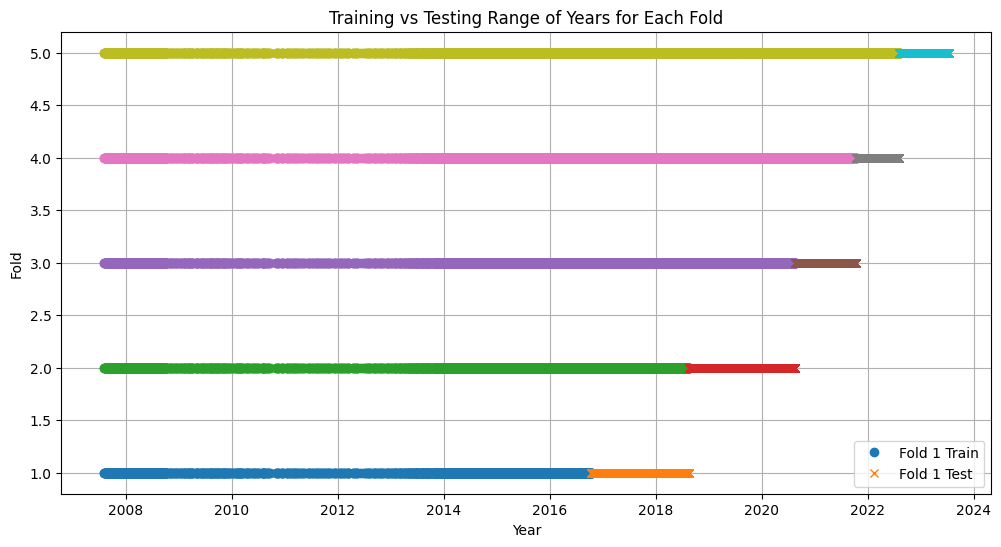

In [20]:
# Plot training vs testing years
plt.figure(figsize=(12, 6))

for i, (train, test) in enumerate(zip(train_dates_list, test_dates_list)):
    plt.plot(train, [i + 1] * len(train), 'o', label=f'Fold {i + 1} Train' if i == 0 else "")
    plt.plot(test, [i + 1] * len(test), 'x', label=f'Fold {i + 1} Test' if i == 0 else "")

plt.xlabel('Year')
plt.ylabel('Fold')
plt.title('Training vs Testing Range of Years for Each Fold')
plt.legend(loc='lower right')
plt.grid()
plt.savefig('training_vs_testing_years.png')
plt.show()



Fold 1 Confusion Matrix:
[[ 328  684]
 [ 393 1134]]


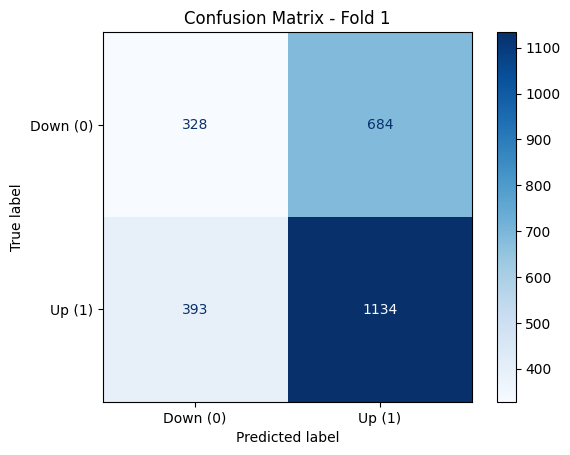

Fold 1 Accuracy: 0.58
Fold 1 MCC: 0.0725
--------------------------------------------------

Fold 2 Confusion Matrix:
[[ 337  719]
 [  79 1404]]


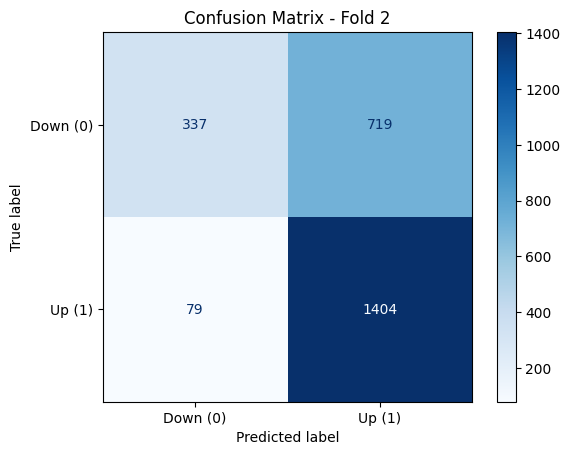

Fold 2 Accuracy: 0.69
Fold 2 MCC: 0.3540
--------------------------------------------------

Fold 3 Confusion Matrix:
[[ 393  522]
 [ 144 1480]]


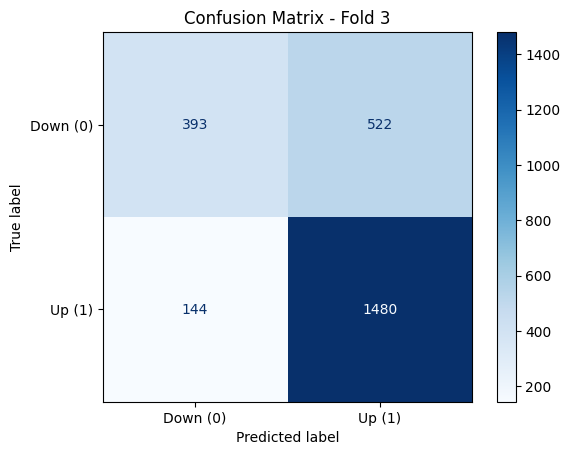

Fold 3 Accuracy: 0.74
Fold 3 MCC: 0.4007
--------------------------------------------------

Fold 4 Confusion Matrix:
[[ 152  978]
 [  17 1392]]


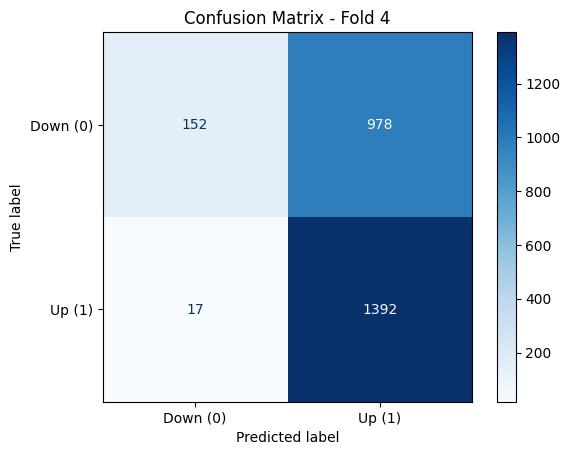

Fold 4 Accuracy: 0.61
Fold 4 MCC: 0.2441
--------------------------------------------------

Fold 5 Confusion Matrix:
[[995 464]
 [219 861]]


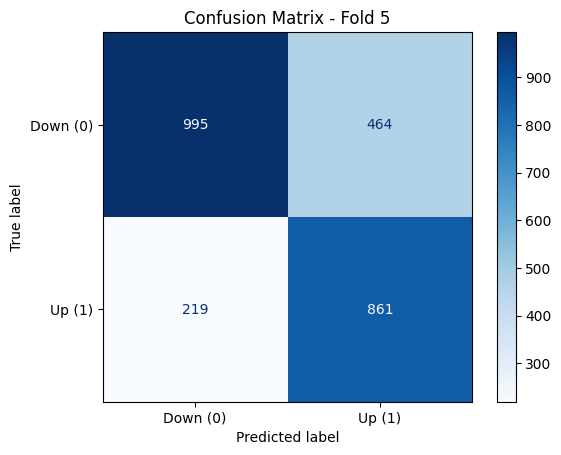

Fold 5 Accuracy: 0.73
Fold 5 MCC: 0.4743
--------------------------------------------------

Average Metrics Across Folds:
Accuracy: 0.67
Precision: 0.65
Recall: 0.88
F1-Score: 0.75
ROC-AUC: 0.74
MCC: 0.31

Overall Financial Metrics on Test Data (TimeSeriesSplit):
Directional Win Rate: 0.45
Profit Factor: 1.73
Sharpe Ratio: 2.59


In [21]:
# ---------------------------
# Assume X and y are NumPy arrays defined as:
# X: shape (n_samples, 782) with the combined market vectors
# y: shape (n_samples,) with binary target values (0 or 1)
#
# Also assume daily_returns is a NumPy array of shape (n_samples,)
# containing the daily return for each corresponding sample.
# For example:
# daily_returns = merged_data['Daily_Return'].values
# ---------------------------

# Initialize TimeSeriesSplit
tss = TimeSeriesSplit(n_splits=5)

# Initialize lists for classification metrics
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []
mcc_scores = []

# This list will store the strategy returns from all folds (in time order)
all_strategy_returns = []
total_test_days = 0  # Count total number of test days across folds

daily_returns = merged_data['Daily_Return'].values

# Perform TimeSeriesSplit
for fold, (train_index, test_index) in enumerate(tss.split(X)):
    # Directly index the NumPy arrays for training and testing splits
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Scale the features using StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Initialize and train the Logistic Regression model
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Evaluate the model using classification metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    mcc = matthews_corrcoef(y_test, y_pred)
    
    # Append metrics for each fold
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    roc_auc_scores.append(roc_auc)
    mcc_scores.append(mcc)
    
    # Print confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\nFold {fold + 1} Confusion Matrix:")
    print(cm)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down (0)", "Up (1)"])
    disp.plot(cmap="Blues")
    disp.ax_.set_title(f"Confusion Matrix - Fold {fold + 1}")
    plt.savefig(f'confusion_matrix_embeddings_tss_fold_{fold+1}_finetuned.png')
    plt.show()
    
    # Print fold metrics
    print(f"Fold {fold + 1} Accuracy: {accuracy:.2f}")
    print(f"Fold {fold + 1} MCC: {mcc:.4f}")
    print("-" * 50)
    
    # ----------------------------------
    # FINANCIAL METRICS CALCULATION per Fold
    # ----------------------------------
    # Retrieve the daily returns for the test period using the test indices.
    # (Assumes daily_returns is aligned with X and y)
    test_returns = daily_returns[test_index]
    
    # Convert predictions into trading positions:
    # For a long-only strategy, use the predictions directly (1 = long, 0 = no trade)
    positions = np.array(y_pred)
    
    # Calculate strategy returns for this fold
    strategy_returns = positions * test_returns
    
    # Append these returns to the overall list and update total test days
    all_strategy_returns.extend(strategy_returns)
    total_test_days += len(strategy_returns)

# -------------------------
# Print Average Classification Metrics Across Folds
# -------------------------
print("\nAverage Metrics Across Folds:")
print(f"Accuracy: {np.mean(accuracy_scores):.2f}")
print(f"Precision: {np.mean(precision_scores):.2f}")
print(f"Recall: {np.mean(recall_scores):.2f}")
print(f"F1-Score: {np.mean(f1_scores):.2f}")
print(f"ROC-AUC: {np.mean(roc_auc_scores):.2f}")
print(f"MCC: {np.mean(mcc_scores):.2f}")

# -------------------------
# Overall Financial Metrics (computed after cross-validation)
# -------------------------
all_strategy_returns = np.array(all_strategy_returns)

if total_test_days == 0:
    directional_win_rate = np.nan
    profit_factor = np.nan
    overall_sharpe = np.nan
    print("No test days available; financial metrics are undefined.")
else:
    # Directional Win Rate: percentage of test days with a positive strategy return
    directional_win_rate = np.sum(all_strategy_returns > 0) / total_test_days
    
    # Profit Factor: sum of all positive returns divided by the absolute sum of all negative returns
    winning_sum = np.sum(all_strategy_returns[all_strategy_returns > 0])
    losing_sum = np.sum(all_strategy_returns[all_strategy_returns < 0])
    profit_factor = winning_sum / abs(losing_sum) if abs(losing_sum) > 1e-10 else np.nan

    # Overall Sharpe Ratio (annualized) using daily returns
    mean_return = np.mean(all_strategy_returns)
    std_return = np.std(all_strategy_returns)
    overall_sharpe = (mean_return / std_return) * np.sqrt(252) if std_return > 1e-10 else 0.0

print("\nOverall Financial Metrics on Test Data (TimeSeriesSplit):")
print(f"Directional Win Rate: {directional_win_rate:.2f}")
print(f"Profit Factor: {profit_factor:.2f}")
print(f"Sharpe Ratio: {overall_sharpe:.2f}")


In [22]:
import joblib
import pathlib

# Find the best fold based on AUC
best_fold_idx = np.argmax(roc_auc_scores)
print(f"\nBest fold: {best_fold_idx + 1} (AUC: {roc_auc_scores[best_fold_idx]:.3f})")

# Retrain on the best fold to get the exact model
train_index, test_index = list(tss.split(X))[best_fold_idx]
X_train_best, X_test_best = X[train_index], X[test_index]
y_train_best, y_test_best = y[train_index], y[test_index]

# Recreate the best model
best_scaler = StandardScaler()
X_train_best_scaled = best_scaler.fit_transform(X_train_best)

best_lr_model = LogisticRegression(random_state=42, max_iter=1000)
best_lr_model.fit(X_train_best_scaled, y_train_best)

# Create artifacts directory and save
ARTIFACT_DIR = pathlib.Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(best_lr_model, ARTIFACT_DIR / 'lr_model.joblib')
joblib.dump(best_scaler, ARTIFACT_DIR / 'full_scaler.joblib')

print(f"✓ Best fold LR model saved to: {ARTIFACT_DIR / 'lr_model.joblib'}")
print(f"✓ Best fold scaler saved to: {ARTIFACT_DIR / 'full_scaler.joblib'}")



Best fold: 5 (AUC: 0.815)
✓ Best fold LR model saved to: artifacts/lr_model.joblib
✓ Best fold scaler saved to: artifacts/full_scaler.joblib



TRAINING FINAL MODEL ON FULL DATASET FOR PRODUCTION
Training final scaler on full dataset...
Training final logistic regression on full dataset...
✓ Final LR model saved to: artifacts/lr_model.joblib
✓ Final scaler saved to: artifacts/final_scaler.joblib


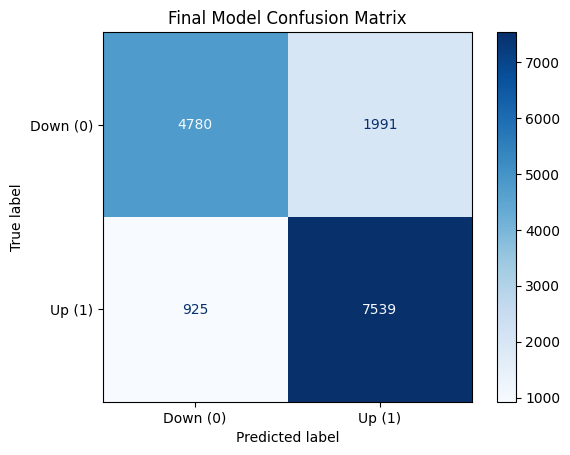


✓ Final model performance on full training dataset:
  Accuracy: 0.809
  Precision: 0.791
  Recall: 0.891
  F1-Score: 0.838
  ROC-AUC: 0.895
  MCC: 0.613
  Model expects 392 features
  Feature vector shape: (15235, 392)

✓ Financial Metrics on Entire Dataset:
  Directional Win Rate: 0.409
  Profit Factor: 2.919
  Sharpe Ratio: 4.283


In [23]:
import joblib
import pathlib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, ConfusionMatrixDisplay
)

# Create artifacts directory
ARTIFACT_DIR = pathlib.Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

print("\n" + "="*50)
print("TRAINING FINAL MODEL ON FULL DATASET FOR PRODUCTION")
print("="*50)

# Train final model on the entire dataset (no cross-validation)
print("Training final scaler on full dataset...")
final_scaler = StandardScaler()
X_final_scaled = final_scaler.fit_transform(X)

print("Training final logistic regression on full dataset...")
final_lr_model = LogisticRegression(random_state=42, max_iter=1000)
final_lr_model.fit(X_final_scaled, y)

# Save the final model and scaler
joblib.dump(final_lr_model, ARTIFACT_DIR / 'lr_model.joblib')
joblib.dump(final_scaler, ARTIFACT_DIR / 'final_scaler.joblib')

print(f"✓ Final LR model saved to: {ARTIFACT_DIR / 'lr_model.joblib'}")
print(f"✓ Final scaler saved to: {ARTIFACT_DIR / 'final_scaler.joblib'}")

# Validate the saved model
y_final_pred = final_lr_model.predict(X_final_scaled)
y_final_prob = final_lr_model.predict_proba(X_final_scaled)[:, 1]

# Additional classification metrics
final_accuracy = accuracy_score(y, y_final_pred)
final_precision = precision_score(y, y_final_pred)
final_recall = recall_score(y, y_final_pred)
final_f1 = f1_score(y, y_final_pred)
final_auc = roc_auc_score(y, y_final_prob)
final_mcc = matthews_corrcoef(y, y_final_pred)

# Print confusion matrix
cm = confusion_matrix(y, y_final_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Down (0)", "Up (1)"])
disp.plot(cmap="Blues")
disp.ax_.set_title("Final Model Confusion Matrix")
plt.savefig('final_model_confusion_matrix.png')
plt.show()

print("\n✓ Final model performance on full training dataset:")
print(f"  Accuracy: {final_accuracy:.3f}")
print(f"  Precision: {final_precision:.3f}")
print(f"  Recall: {final_recall:.3f}")
print(f"  F1-Score: {final_f1:.3f}")
print(f"  ROC-AUC: {final_auc:.3f}")
print(f"  MCC: {final_mcc:.3f}")
print(f"  Model expects {final_lr_model.n_features_in_} features")
print(f"  Feature vector shape: {X.shape}")

# Financial metrics calculation
positions = np.array(y_final_pred)
strategy_returns = positions * daily_returns

# Directional Win Rate
directional_win_rate = np.mean(strategy_returns > 0)

# Profit Factor
winning_sum = np.sum(strategy_returns[strategy_returns > 0])
losing_sum = np.sum(strategy_returns[strategy_returns < 0])
profit_factor = winning_sum / abs(losing_sum) if abs(losing_sum) > 1e-10 else np.nan

# Sharpe Ratio (annualized)
mean_return = np.mean(strategy_returns)
std_return = np.std(strategy_returns)
sharpe_ratio = (mean_return / std_return) * np.sqrt(252) if std_return > 1e-10 else 0.0

print("\n✓ Financial Metrics on Entire Dataset:")
print(f"  Directional Win Rate: {directional_win_rate:.3f}")
print(f"  Profit Factor: {profit_factor:.3f}")
print(f"  Sharpe Ratio: {sharpe_ratio:.3f}")